## Evaluation of the routing decisions of main agent

### Imports and setup

In [87]:
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [31]:
from dotenv import load_dotenv
import os

load_dotenv()

openai_key = os.getenv("OPENAI_API_KEY")
client = OpenAI()
print(openai_key[:5])

sk-pr


### loading the labeled dataset - sms_conversations.json

In [32]:
file_path = "C:\\AI_Projects\\Genai_final_project\\sms_conversations.json"

with open(file_path, "r", encoding="utf-8") as f:
    conversations = json.load(f)

print(f"Loaded {len(conversations)} conversations")


Loaded 15 conversations


### preparing the data set to an Open AI evaluation ready format

In [33]:

def build_eval_samples(conversations):
    samples = []

    for conv in conversations:
        history = []

        for turn in conv["turns"]:
            history.append({
                "role": turn["speaker"],
                "content": turn["text"]
            })

            # Only recruiter turns have labels
            if turn["speaker"] == "recruiter" and turn["label"] is not None:
                samples.append({
                    "conversation_id": conv["conversation_id"],
                    "turn_id": turn["turn_id"],
                    "chat_history": history.copy(),
                    "expected": turn["label"]
                })

    return samples


samples = build_eval_samples(conversations)

print(f"Total eval samples: {len(samples)}")



Total eval samples: 59


In [34]:
# Checking the spread of labels in the dataset - looks quite even --> OK
label_counts = {}

for sample in samples:
    label = sample["expected"]
    if label not in label_counts:
        label_counts[label] = 0
    label_counts[label] += 1

label_counts

{'continue': 25, 'schedule': 19, 'end': 15}

In [53]:
def format_chat_history(chat_history):
    formatted = ""
    for turn in chat_history:
        role = turn["role"]
        content = turn["content"]
        formatted += f"{role.upper()}: {content}\n"
    return formatted.strip()


jsonl_path = "C:\\AI_Projects\\Genai_final_project\\tests\\routing_eval_dataset.jsonl"

with open(jsonl_path, "w", encoding="utf-8") as f:
    for sample in samples:
        row = {
            "item": {
                "input": format_chat_history(sample["chat_history"]),
                "expected_output": sample["expected"]
            }
        }
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print(f"JSONL dataset saved to {jsonl_path}")

JSONL dataset saved to C:\AI_Projects\Genai_final_project\tests\routing_eval_dataset.jsonl


In [54]:
with open(jsonl_path, "r", encoding="utf-8") as f:
    for i in range(3):
        print(f.readline())

{"item": {"input": "RECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?", "expected_output": "continue"}}

{"item": {"input": "RECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Our engineering manager can interview you Wednesday at 10 AM or Thursday at 2 PM. Which works best?", "expected_output": "schedule"}}

{"item": {"input": "RECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Our engineering manager can interview you Wednesday at 10 AM or Thursday at 2 PM. Which works best?\nCANDIDATE: I can't at that time—I'm busy.\nRECRUITER: No problem. How about Thursday at 4 PM

### Upload dataset to Open AI platform

In [56]:
with open(jsonl_path, "rb") as f:
    uploaded_file = client.files.create(
        file=f,
        purpose="evals"
    )

print(uploaded_file)
print(uploaded_file.id)

FileObject(id='file-6sM2rfhRtARViiJb54q214', bytes=24793, created_at=1776690312, filename='routing_eval_dataset.jsonl', object='file', purpose='evals', status='processed', expires_at=None, status_details=None)
file-6sM2rfhRtARViiJb54q214


In [55]:
with open(jsonl_path, "r", encoding="utf-8") as f:
    print(f.readline())

{"item": {"input": "RECRUITER: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?", "expected_output": "continue"}}



### Create the eval definition

In [52]:
routing_eval = client.evals.create(
    name="Routing Decision Eval",
    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "input": {"type": "string"},
                "expected_output": {"type": "string"},
            },
            "required": ["input", "expected_output"],
        },
        "include_sample_schema": True,
    },
    testing_criteria=[
        {
            "type": "string_check",
            "name": "Match output to human label",
            "input": "{{ sample.output_text }}",
            "operation": "eq",
            "reference": "{{ item.expected_output }}"
        }
    ],
)

print(routing_eval)
print(routing_eval.id)

EvalCreateResponse(id='eval_69e623c056dc8191b30673549e7f5240', created_at=1776690112, data_source_config=EvalCustomDataSourceConfig(schema_={'type': 'object', 'properties': {'item': {'type': 'object', 'properties': {'input': {'type': 'string'}, 'expected_output': {'type': 'string'}}, 'required': ['input', 'expected_output']}, 'sample': {'type': 'object', 'properties': {'model': {'type': 'string'}, 'choices': {'type': 'array', 'items': {'type': 'object', 'properties': {'message': {'type': 'object', 'properties': {'role': {'type': 'string', 'enum': ['assistant']}, 'content': {'type': ['string', 'array', 'null']}, 'refusal': {'type': ['boolean', 'null']}, 'tool_calls': {'type': ['array', 'null'], 'items': {'type': 'object', 'properties': {'type': {'type': 'string', 'enum': ['function']}, 'function': {'type': 'object', 'properties': {'name': {'type': 'string'}, 'arguments': {'type': 'string'}}, 'required': ['name', 'arguments']}, 'id': {'type': 'string'}}, 'required': ['type', 'function', 

### Create the eval run

In [60]:
MODEL_NAME = os.getenv("OPENAI_MODEL", "gpt-5.4")

routing_instructions = """
You are evaluating the routing decision of a recruiting chatbot.

Given the full conversation so far, return ONLY one of these exact labels:
continue
schedule
end

Definitions:
- continue: continue the conversation, answer questions, or gather more information
- schedule: move the conversation toward interview scheduling or respond to scheduling-related messages
- end: end the conversation because the candidate is no longer interested, asked to stop, or the conversation is concluded

Important rules:
- If the candidate asks for information or answers a question, return continue
- If the candidate wants to schedule, accepts a time, asks for another time, or discusses interview timing, return schedule
- If the candidate opts out, is no longer interested, asks to stop, or the conversation is clearly concluded, return end

Return only the label, with no explanation and no JSON.
"""

routing_run = client.evals.runs.create(
    routing_eval.id,
    name="Routing baseline run",
    data_source={
        "type": "completions",
        "model": MODEL_NAME,
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": routing_instructions},
                {"role": "user", "content": "{{ item.input }}"},
            ],
        },
        "source": {
            "type": "file_id",
            "id": uploaded_file.id,
        },
    },
)

print(routing_run)
print(routing_run.id)

RunCreateResponse(id='evalrun_69e625ea4768819182fb6b81773c41ce', created_at=1776690666, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-6sM2rfhRtARViiJb54q214', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content='\nYou are evaluating the routing decision of a recruiting chatbot.\n\nGiven the full conversation so far, return ONLY one of these exact labels:\ncontinue\nschedule\nend\n\nDefinitions:\n- continue: continue the conversation, answer questions, or gather more information\n- schedule: move the conversation toward interview scheduling or respond to scheduling-related messages\n- end: end the conversation because the candidate is no longer interested, asked to stop, or the conversation is concluded\n\nImportant rules:\n- If the candidate asks for information or answers a question, return continue\n- If the candidate wants to schedule, accepts a time, asks for another time, or discusses interview 

### Retrieve results and analyzing

In [65]:
run_retrieve = client.evals.runs.retrieve(
    eval_id=routing_eval.id,
    run_id=routing_run.id
)

print("Status:", run_retrieve.status)
print("Result counts:", run_retrieve.result_counts)
print("Report URL:", run_retrieve.report_url)


Status: completed
Result counts: ResultCounts(errored=0, failed=4, passed=55, total=59)
Report URL: https://platform.openai.com/evaluations/eval_69e623c056dc8191b30673549e7f5240?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e625ea4768819182fb6b81773c41ce


In [66]:
passed = run_retrieve.result_counts.passed
total = run_retrieve.result_counts.total

accuracy = passed / total

print(f"Accuracy:, {accuracy:.2%}")

Accuracy:, 93.22%


In [79]:
# Retrieve all items for a specific eval run

items = client.evals.runs.output_items.list(
    eval_id=routing_eval.id,
    run_id=routing_run.id
    )


items_list = list(items)

In [81]:
# Extract ground truth and predictions
y_true = [item.datasource_item['expected_output'] for item in items]
y_pred = [item.sample.output[0].content.strip() for item in items]

In [82]:
# Compute metrics accuracy_score
print('accuracy_score')
print(accuracy_score(y_true, y_pred))

accuracy_score
0.9322033898305084


In [84]:
labels = sorted(set(y_true) | set(y_pred))
print(labels)

['continue', 'end', 'schedule']


In [85]:
cm = confusion_matrix(y_true, y_pred, labels=labels)


df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix:\n")
print(df_cm)

Confusion Matrix:

          continue  end  schedule
continue        24    0         1
end              0   12         3
schedule         0    0        19


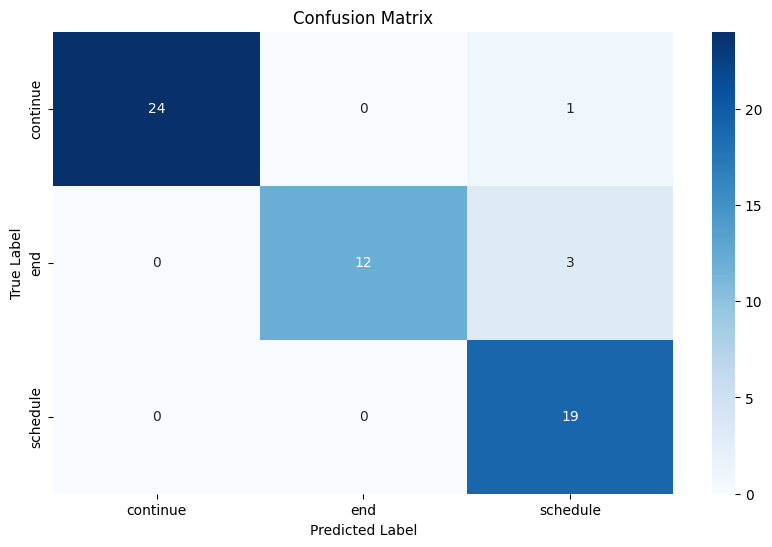

In [88]:
for idx, label in enumerate(labels):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

### Analyze failed cases

In [67]:
run_retrieve.report_url

'https://platform.openai.com/evaluations/eval_69e623c056dc8191b30673549e7f5240?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e625ea4768819182fb6b81773c41ce'

In [83]:
failed_items = client.evals.runs.output_items.list(
    eval_id=routing_eval.id,
    run_id=routing_run.id,
    status="fail",
    limit=1
)

print(failed_items)

SyncCursorPage[OutputItemListResponse](data=[OutputItemListResponse(id='outputitem_69e625f0309c8191a11a1515963fdb6e', created_at=1776690672, datasource_item={'input': "RECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?\nCANDIDATE: Sure, I have four years of Python experience.\nRECRUITER: How about an interview Monday at 3\u202fPM or Tuesday at 11\u202fAM?\nCANDIDATE: I can't at that time—I'm busy.\nRECRUITER: Alright, would Wednesday at 1\u202fPM work?\nCANDIDATE: Tuesday at 10\u202fAM works.\nRECRUITER: Excellent, the slot is reserved. Looking forward to speaking with you!", 'expected_output': 'end'}, datasource_item_id=55, eval_id='eval_69e623c056dc8191b30673549e7f5240', object='eval.run.output_item', results=[Result(name='Match output to human label-42f66429-7ae1-4e11-b0b1-05612842f2e5', passed=False, score=0.0, sample=None, type=None)], run_id='evalrun_69e625ea4768819182fb6b81773c41ce', sample=Sam

In [76]:
for i, failed in enumerate(failed_items.data, start=1):
    print("=" * 100)
    print(f"FAILED CASE {i}")
    print("=" * 100)

    print("\nINPUT:\n")
    print(failed.datasource_item["input"])

    print("\nEXPECTED:\n")
    print(failed.datasource_item["expected_output"])

    print("\nMODEL OUTPUT:\n")
    print(failed.sample.output[0].content)

    print("\nRESULTS:\n")
    print(failed.results)
    print()

FAILED CASE 1

INPUT:

RECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
CANDIDATE: Sure, I have four years of Python experience.
RECRUITER: How about an interview Monday at 3 PM or Tuesday at 11 AM?
CANDIDATE: I can't at that time—I'm busy.
RECRUITER: Alright, would Wednesday at 1 PM work?
CANDIDATE: Tuesday at 10 AM works.
RECRUITER: Excellent, the slot is reserved. Looking forward to speaking with you!

EXPECTED:

end

MODEL OUTPUT:

schedule

RESULTS:

[Result(name='Match output to human label-42f66429-7ae1-4e11-b0b1-05612842f2e5', passed=False, score=0.0, sample=None, type=None)]

FAILED CASE 2

INPUT:

RECRUITER: Hello! I saw your application for the Python Developer position—how long have you been working with Python?
CANDIDATE: I've been using Python professionally for five years, mostly for data analysis.
RECRUITER: Are you also using SQL in addition to Python?
CANDIDATE: Yes, SQL is a big p

### Improve main agent prompt to match 

In [121]:
# create a new EVAL with improved prompt

MODEL_NAME = os.getenv("OPENAI_MODEL", "gpt-5.4")

routing_instructions = """
You are evaluating the routing decision of a recruiting chatbot.

Given the full conversation so far, return ONLY one of these exact labels:
continue
schedule
end

Definitions:
- continue: continue the conversation, answer questions, gather more information, or send a mainly informational reply
- schedule: actively move the conversation through interview scheduling, propose times, negotiate times, or respond to scheduling-related messages
- end: end the conversation because the candidate is no longer interested, asked to stop, or the conversation has already been concluded

Important rules:
- If the candidate asks for information or the recruiter is mainly answering a question, return continue
- If the conversation is actively choosing, proposing, changing, or confirming an interview time, return schedule
- If the recruiter's or candidate's message says the interview is booked, confirmed, reserved, or that a calendar invite will be sent, return end
- If the recruiter's message is mostly informational and only lightly suggests a future meeting, for the first time prefer continue over schedule
- If the candidate opts out, is no longer interested, asks to stop, or the conversation is clearly concluded, return end

Return only the label, with no explanation and no JSON.
"""

routing_run = client.evals.runs.create(
    routing_eval.id,
    name="Routing baseline run",
    data_source={
        "type": "completions",
        "model": MODEL_NAME,
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": routing_instructions},
                {"role": "user", "content": "{{ item.input }}"},
            ],
        },
        "source": {
            "type": "file_id",
            "id": uploaded_file.id,
        },
    },
)

print(routing_run)
print(routing_run.id)

RunCreateResponse(id='evalrun_69e64a5f98648191bc5d316a5bcd64d4', created_at=1776699999, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-6sM2rfhRtARViiJb54q214', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content="\nYou are evaluating the routing decision of a recruiting chatbot.\n\nGiven the full conversation so far, return ONLY one of these exact labels:\ncontinue\nschedule\nend\n\nDefinitions:\n- continue: continue the conversation, answer questions, gather more information, or send a mainly informational reply\n- schedule: actively move the conversation through interview scheduling, propose times, negotiate times, or respond to scheduling-related messages\n- end: end the conversation because the candidate is no longer interested, asked to stop, or the conversation has already been concluded\n\nImportant rules:\n- If the candidate asks for information or the recruiter is mainly answering a question,

In [122]:
# retrieving results
run_retrieve = client.evals.runs.retrieve(
    eval_id=routing_eval.id,
    run_id=routing_run.id
)

print("Status:", run_retrieve.status)
print("Result counts:", run_retrieve.result_counts)
print("Report URL:", run_retrieve.report_url)

Status: completed
Result counts: ResultCounts(errored=0, failed=2, passed=57, total=59)
Report URL: https://platform.openai.com/evaluations/eval_69e623c056dc8191b30673549e7f5240?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e64a5f98648191bc5d316a5bcd64d4


In [123]:
# Retrieve all items for a specific eval run

items = client.evals.runs.output_items.list(
    eval_id=routing_eval.id,
    run_id=routing_run.id
    )


items_list = list(items)

In [124]:
# Extract ground truth and predictions
y_true = [item.datasource_item['expected_output'] for item in items]
y_pred = [item.sample.output[0].content.strip() for item in items]

In [125]:
# Compute metrics accuracy_score
print('accuracy_score')
print(accuracy_score(y_true, y_pred))

accuracy_score
0.9661016949152542


Confusion Matrix:

          continue  end  schedule
continue        23    1         1
end              0   15         0
schedule         0    0        19


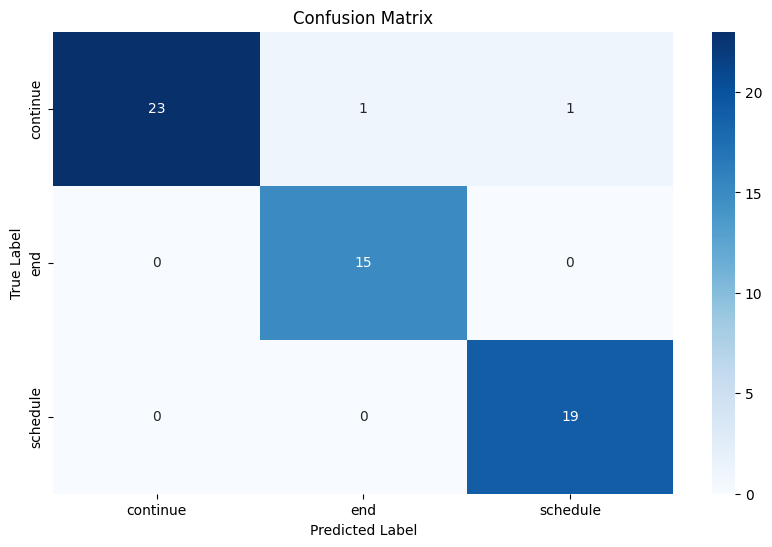

In [126]:
# confusion matrix

cm = confusion_matrix(y_true, y_pred, labels=labels)


df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix:\n")
print(df_cm)

for idx, label in enumerate(labels):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [127]:
failed_items = client.evals.runs.output_items.list(
    eval_id=routing_eval.id,
    run_id=routing_run.id,
    status="fail"
)

print(failed_items)

SyncCursorPage[OutputItemListResponse](data=[OutputItemListResponse(id='outputitem_69e64a6506d081918c68767e87d17a54', created_at=1776700005, datasource_item={'input': "RECRUITER: Hello! I saw your application for the Python Developer position—how long have you been working with Python?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Are you also using SQL in addition to Python?\nCANDIDATE: Yes, SQL is a big part of my job. Is the position fully remote or hybrid?\nRECRUITER: Hybrid work model, with at least two days of remote work per week, will you be able to meet next Wednesday at 10\u202fAM", 'expected_output': 'continue'}, datasource_item_id=15, eval_id='eval_69e623c056dc8191b30673549e7f5240', object='eval.run.output_item', results=[Result(name='Match output to human label-42f66429-7ae1-4e11-b0b1-05612842f2e5', passed=False, score=0.0, sample=None, type=None)], run_id='evalrun_69e64a5f98648191bc5d316a5bcd64d4', sample=Sample(er

In [128]:
for i, failed in enumerate(failed_items.data, start=1):
    print("=" * 100)
    print(f"FAILED CASE {i}")
    print("=" * 100)

    print("\nINPUT:\n")
    print(failed.datasource_item["input"])

    print("\nEXPECTED:\n")
    print(failed.datasource_item["expected_output"])

    print("\nMODEL OUTPUT:\n")
    print(failed.sample.output[0].content)

    print("\nRESULTS:\n")
    print(failed.results)
    print()

FAILED CASE 1

INPUT:

RECRUITER: Hello! I saw your application for the Python Developer position—how long have you been working with Python?
CANDIDATE: I've been using Python professionally for five years, mostly for data analysis.
RECRUITER: Are you also using SQL in addition to Python?
CANDIDATE: Yes, SQL is a big part of my job. Is the position fully remote or hybrid?
RECRUITER: Hybrid work model, with at least two days of remote work per week, will you be able to meet next Wednesday at 10 AM

EXPECTED:

continue

MODEL OUTPUT:

schedule

RESULTS:

[Result(name='Match output to human label-42f66429-7ae1-4e11-b0b1-05612842f2e5', passed=False, score=0.0, sample=None, type=None)]

FAILED CASE 2

INPUT:

RECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
CANDIDATE: I've been using Python professionally for five years, mostly for data analysis.
RECRUITER: Our engineering manager can interview you Wedne

In [141]:
routing_instructions = """
You are evaluating the routing decision of a recruiting chatbot.

Given the full conversation so far, return ONLY one of these exact labels:
continue
schedule
end

Definitions:
- continue: continue the conversation, answer questions, gather more information, or send a mainly informational reply
- schedule: actively move the conversation through interview scheduling, including proposing, negotiating, or confirming an interview meeting
- end: end the conversation because the candidate is no longer interested, asked to stop, or the conversation has already been fully concluded with no further substantive reply needed

Important rules:
- If the candidate asks for information or the recruiter is mainly answering a question, return continue
- If the recruiter message mainly provides information, return continue even if it also mentions that the interview is confirmed or booked
- Use end only when the message mainly closes the conversation, such as a short wrap-up after booking, a goodbye, or acknowledging opt-out
- If the conversation is actively choosing, proposing, changing, negotiating, or setting up an interview, return schedule
- If the recruiter’s message is mostly informational and only lightly suggests a future meeting for the first time, prefer continue over schedule
- If the candidate opts out, is no longer interested, asks to stop, or the conversation is clearly concluded, return end

Borderline examples:

Example 1:
CHAT:
RECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
CANDIDATE: I've been using Python professionally for five years, mostly for data analysis.
RECRUITER: Our engineering manager can interview you Wednesday at 10 AM or Thursday at 2 PM. Which works best?
CANDIDATE: Tuesday at 10 AM works. But can I get more details about the position?
RECRUITER: Great, your interview is confirmed. Sure, We're looking for a skilled Python Developer with expertise in Python 3 and experience working with frameworks such as Django, Flask, or FastAPI. The ideal candidate should be familiar with building RESTful APIs, working with SQL or NoSQL databases, and using version control systems like Git.

LABEL:
continue

Example 2:
CHAT:
RECRUITER: Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
CANDIDATE: I have three years' experience with Pyhon and AWS.
RECRUITER: Could you elaborate on your experience with cloud platforms like AWS?
CANDIDATE: I've worked a bit with AWS, mainly for deploying small apps and managing storage, but I'm still gaining experience and open to learning more.
RECRUITER: I see, the role focuses on building backend services in Python, mainly FastAPI.
CANDIDATE: Sounds very interesting, I'm confident I can handle it
RECRUITER: Great, Can we set up a meeting next Tuesday

LABEL:
schedule

Return only the label, with no explanation and no JSON.
"""

routing_run = client.evals.runs.create(
    routing_eval.id,
    name="Routing baseline run",
    data_source={
        "type": "completions",
        "model": MODEL_NAME,
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": routing_instructions},
                {"role": "user", "content": "{{ item.input }}"},
            ],
        },
        "source": {
            "type": "file_id",
            "id": uploaded_file.id,
        },
    },
)

print(routing_run)
print(routing_run.id)

RunCreateResponse(id='evalrun_69e65639e744819180580661b2f2befc', created_at=1776703033, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-6sM2rfhRtARViiJb54q214', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content="\nYou are evaluating the routing decision of a recruiting chatbot.\n\nGiven the full conversation so far, return ONLY one of these exact labels:\ncontinue\nschedule\nend\n\nDefinitions:\n- continue: continue the conversation, answer questions, gather more information, or send a mainly informational reply\n- schedule: actively move the conversation through interview scheduling, including proposing, negotiating, or confirming an interview meeting\n- end: end the conversation because the candidate is no longer interested, asked to stop, or the conversation has already been fully concluded with no further substantive reply needed\n\nImportant rules:\n- If the candidate asks for information or the

In [142]:
# retrieving results
run_retrieve = client.evals.runs.retrieve(
    eval_id=routing_eval.id,
    run_id=routing_run.id
)

print("Status:", run_retrieve.status)
print("Result counts:", run_retrieve.result_counts)
print("Report URL:", run_retrieve.report_url)

Status: completed
Result counts: ResultCounts(errored=0, failed=1, passed=58, total=59)
Report URL: https://platform.openai.com/evaluations/eval_69e623c056dc8191b30673549e7f5240?project_id=proj_8zitnyhiCTnafpLngsEEtrd7&run_id=evalrun_69e65639e744819180580661b2f2befc


In [143]:
failed_items = client.evals.runs.output_items.list(
    eval_id=routing_eval.id,
    run_id=routing_run.id,
    status="fail"
)

print(failed_items)

SyncCursorPage[OutputItemListResponse](data=[OutputItemListResponse(id='outputitem_69e6563c1af081919928e2bf7fce983d', created_at=1776703036, datasource_item={'input': "RECRUITER: Hello! I saw your application for the Python Developer position—how long have you been working with Python?\nCANDIDATE: I've been using Python professionally for five years, mostly for data analysis.\nRECRUITER: Are you also using SQL in addition to Python?\nCANDIDATE: Yes, SQL is a big part of my job. Is the position fully remote or hybrid?\nRECRUITER: Hybrid work model, with at least two days of remote work per week, will you be able to meet next Wednesday at 10\u202fAM", 'expected_output': 'continue'}, datasource_item_id=15, eval_id='eval_69e623c056dc8191b30673549e7f5240', object='eval.run.output_item', results=[Result(name='Match output to human label-42f66429-7ae1-4e11-b0b1-05612842f2e5', passed=False, score=0.0, sample=None, type=None)], run_id='evalrun_69e65639e744819180580661b2f2befc', sample=Sample(er

In [144]:
for i, failed in enumerate(failed_items.data, start=1):
    print("=" * 100)
    print(f"FAILED CASE {i}")
    print("=" * 100)

    print("\nINPUT:\n")
    print(failed.datasource_item["input"])

    print("\nEXPECTED:\n")
    print(failed.datasource_item["expected_output"])

    print("\nMODEL OUTPUT:\n")
    print(failed.sample.output[0].content)

    print("\nRESULTS:\n")
    print(failed.results)
    print()

FAILED CASE 1

INPUT:

RECRUITER: Hello! I saw your application for the Python Developer position—how long have you been working with Python?
CANDIDATE: I've been using Python professionally for five years, mostly for data analysis.
RECRUITER: Are you also using SQL in addition to Python?
CANDIDATE: Yes, SQL is a big part of my job. Is the position fully remote or hybrid?
RECRUITER: Hybrid work model, with at least two days of remote work per week, will you be able to meet next Wednesday at 10 AM

EXPECTED:

continue

MODEL OUTPUT:

schedule

RESULTS:

[Result(name='Match output to human label-42f66429-7ae1-4e11-b0b1-05612842f2e5', passed=False, score=0.0, sample=None, type=None)]



### Model prompt was improved to 98% accuracy with improved rules and few shots